In [1]:
import numpy as np
import pandas as pd

hosts = {
    1964: 'JPN',
    1968: 'MEX',
    1972: 'GER',
    1976: 'CAN',
    1988: 'KOR',
    1992: 'ESP',
    1996: 'USA', 
    2000: 'AUS', 
    2004: 'GRE', 
    2008: 'CHN', 
    2012: 'GBR', 
    2016: 'BRA',
    2020: 'JPN',
    2024: 'FRA'
}

noc_to_iso = {
    "ALG" : "DZA", "ANG" : "AGO",
    "ANT" : "ATG", "ANZ" : "AUS",
    "ARU" : "ABW", "ASA" : "ASM",
    "BAH" : "BHS", "BAN" : "BGD",
    "BAR" : "BRB", "BRD" : "BDI",
    "BER" : "BMU", "BHU" : "BTN",
    "BIZ" : "BLZ", "BOH" : "CZE",
    "BOT" : "BWA", "BRN" : "BHR",
    "BRU" : "BRN", "BUL" : "BGR",
    "BUR" : "BFA", "CAM" : "KHM",
    "CAY" : "CYM", "CGO" : "COG",
    "CHA" : "TCD", "CHI" : "CHL",
    "CRC" : "CRI", "CRO" : "HRV",
    "CRT" : "GRC", "DEN" : "DNK", 
    "EUN" : "RUS", "FRG" : "DEU", 
    "GDR" : "DEU", "SAA" : "DEU", 
    "URS" : "RUS", "ROC" : "RUS",
    "ESA" : "SLV", "FIJ" : "FJI",
    "GAM" : "GMB", "GBS" : "GNB",
    "GEQ" : "GNQ", "GER" : "DEU",
    "GRN" : "GRD", "GUA" : "GTM",
    "GUI" : "GIN", "HAI" : "HTI",
    "HON" : "HND", "INA" : "IDN",
    "IRI" : "IRN", "ISV" : "VIR",
    "IVB" : "VGB", "KOS" : "XKX",
    "KSA" : "SAU", "KUW" : "KWT",
    "LAT" : "LVA", "LBA" : "LBY",
    "LES" : "LSO", "LIB" : "LBN",
    "MAD" : "MDG", "MAL" : "MYS",
    "MAS" : "MYS", "MAW" : "MWI",
    "MGL" : "MNG", "MON" : "MCO",
    "MRI" : "MUS", "MTN" : "MRT",
    "MYA" : "MMR", "NCA" : "NIC",
    "NED" : "NLD", "NEP" : "NPL",
    "NGR" : "NGA", "NIG" : "NER",
    "OMA" : "OMN", "PAR" : "PRY",
    "PHI" : "PHL", "POR" : "PRT",
    "PUR" : "PRI", "RHO" : "ZWE",
    "ZIM" : "ZWE", "RSA" : "ZAF",
    "SAM" : "WSM", "SCG" : "SRB",
    "SEY" : "SYC", "SIN" : "SGP",
    "SKN" : "KNA", "SLO" : "SVN",
    "SOL" : "SLB", "SRI" : "LKA",
    "SUD" : "SDN", "SUI" : "CHE",
    "TAN" : "TZA", "TCH" : "CZE",
    "TGA" : "TON", "TOG" : "TGO",
    "UAE" : "ARE", "URU" : "URY",
    "VAN" : "VUT", "VIE" : "VNM",
    "VIN" : "VCT", "ZAM" : "ZMB"
}

old_to_new_noc = {
    "GDR" : "GER", "FRG" : "GER", "SAA" : "GER",
    "EUN" : "RUS", "URS" : "RUS", "ROC" : "RUS"
}

In [2]:
df = pd.read_csv('./data/athlete_events.csv')
df_summer_modern = df[(df['Year'] >= 1964) & (df['Season']=='Summer') & (df['Year'] != 1980) & (df['Year'] != 1984)]
df_summer_modern = df_summer_modern.drop_duplicates(subset=['NOC', 'Games', 'Sport', 'Event', 'Medal'])
df_summer_modern.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,FIN,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,FIN,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,FIN,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN


In [3]:
df_summer_modern['fixed_noc'] = df_summer_modern['NOC'].map(old_to_new_noc).fillna(df_summer_modern['NOC'])
df_summer_modern = df_summer_modern.drop(columns=['NOC'])
df_summer_modern = df_summer_modern.rename(columns={'fixed_noc' : 'NOC'})
df_summer_modern.head()

,ID,Name,Sex,Age,Height,Weight,Team,Games,Year,Season,City,Sport,Event,Medal,NOC
0,1,A Dijiang,M,24.0,180.0,80.0,China,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,CHN
1,2,A Lamusi,M,23.0,170.0,60.0,China,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,CHN
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,NaN,FIN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,NaN,FIN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,NaN,FIN


In [4]:
df_summer_modern['Medal'] = df_summer_modern['Medal'].notna().astype(int)
df_summer_modern.head()

,ID,Name,Sex,Age,Height,Weight,Team,Games,Year,Season,City,Sport,Event,Medal,NOC
0,1,A Dijiang,M,24.0,180.0,80.0,China,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,0,CHN
1,2,A Lamusi,M,23.0,170.0,60.0,China,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,0,CHN
31,12,Jyri Tapani Aalto,M,31.0,172.0,70.0,Finland,2000 Summer,2000,Summer,Sydney,Badminton,Badminton Men's Singles,0,FIN
32,13,Minna Maarit Aalto,F,30.0,159.0,55.5,Finland,1996 Summer,1996,Summer,Atlanta,Sailing,Sailing Women's Windsurfer,0,FIN
33,13,Minna Maarit Aalto,F,34.0,159.0,55.5,Finland,2000 Summer,2000,Summer,Sydney,Sailing,Sailing Women's Windsurfer,0,FIN


In [5]:
df_summer_modern = df_summer_modern.groupby(['NOC', 'Year'])['Medal'].sum().reset_index()
df_summer_modern.head()

,NOC,Year,Medal
0,AFG,1964,0
1,AFG,1968,0
2,AFG,1972,0
3,AFG,1988,0
4,AFG,1996,0


In [6]:
df_last_years = pd.read_csv('data/country-medals-by-year_missing_2018-2026.csv')
df_last_years = df_last_years[df_last_years['Season']=='Summer']
df_last_years = df_last_years.drop(columns=['Gold', 'Silver', 'Bronze'])
df_last_years = df_last_years.drop(columns=['Season'])
df_last_years = df_last_years.rename(columns={'Total_Medals' : 'Medal'})
df_last_years.head()

,Year,NOC,Medal
30,2020,USA,113
31,2020,CHN,89
32,2020,JPN,58
33,2020,GBR,64
34,2020,ROC,71


In [7]:
df_last_years['fixed_noc'] = df_last_years['NOC'].map(old_to_new_noc).fillna(df_last_years['NOC'])
df_last_years = df_last_years.drop(columns=['NOC'])
df_last_years = df_last_years.rename(columns={'fixed_noc' : 'NOC'})
df_last_years.head()

,Year,Medal,NOC
30,2020,113,USA
31,2020,89,CHN
32,2020,58,JPN
33,2020,64,GBR
34,2020,71,RUS


In [8]:
df_olympics = pd.concat([df_summer_modern, df_last_years], ignore_index=True)
df_olympics.tail()

,NOC,Year,Medal
2136,QAT,2024,1
2137,EOR,2024,1
2138,SGP,2024,1
2139,SVK,2024,1
2140,ZAM,2024,1


In [9]:
df_olympics.groupby(['Year'])['Medal'].sum()

Year
1964     501
1968     527
1972     600
1976     613
1988     738
1992     813
1996     841
2000     925
2004     927
2008     957
2012     962
2016     973
2020    1080
2024    1044
Name: Medal, dtype: int64

In [10]:
def check_host(row):
    if row['Year'] in hosts and row['NOC'] == hosts[row['Year']]:
        return 1
    else:
        return 0

df_olympics['is_host'] = df_olympics.apply(check_host, axis=1)
df_olympics.head()

,NOC,Year,Medal,is_host
0,AFG,1964,0,0
1,AFG,1968,0,0
2,AFG,1972,0,0
3,AFG,1988,0,0
4,AFG,1996,0,0


In [11]:
df_olympics[df_olympics['is_host']==1]

,NOC,Year,Medal,is_host
105,AUS,2000,58,1
261,BRA,2016,19,1
316,CAN,1976,11,1
372,CHN,2008,100,1
564,ESP,1992,22,1
655,GBR,2012,65,1
679,GER,1972,106,1
708,GRE,2004,16,1
939,JPN,1964,29,1
982,KOR,1988,33,1


In [12]:
df_olympics['Percentage'] = (df_olympics['Medal'] / df_olympics.groupby('Year')['Medal'].transform('sum')) * 100

In [13]:
host_list = list(hosts.values())
df_olympics_hosts = df_olympics[df_olympics['NOC'].isin(host_list)]
df_olympics_hosts.head()

,NOC,Year,Medal,is_host,Percentage
98,AUS,1964,18,0,3.592814
99,AUS,1968,17,0,3.225806
100,AUS,1972,17,0,2.833333
101,AUS,1976,5,0,0.815661
102,AUS,1988,14,0,1.897019


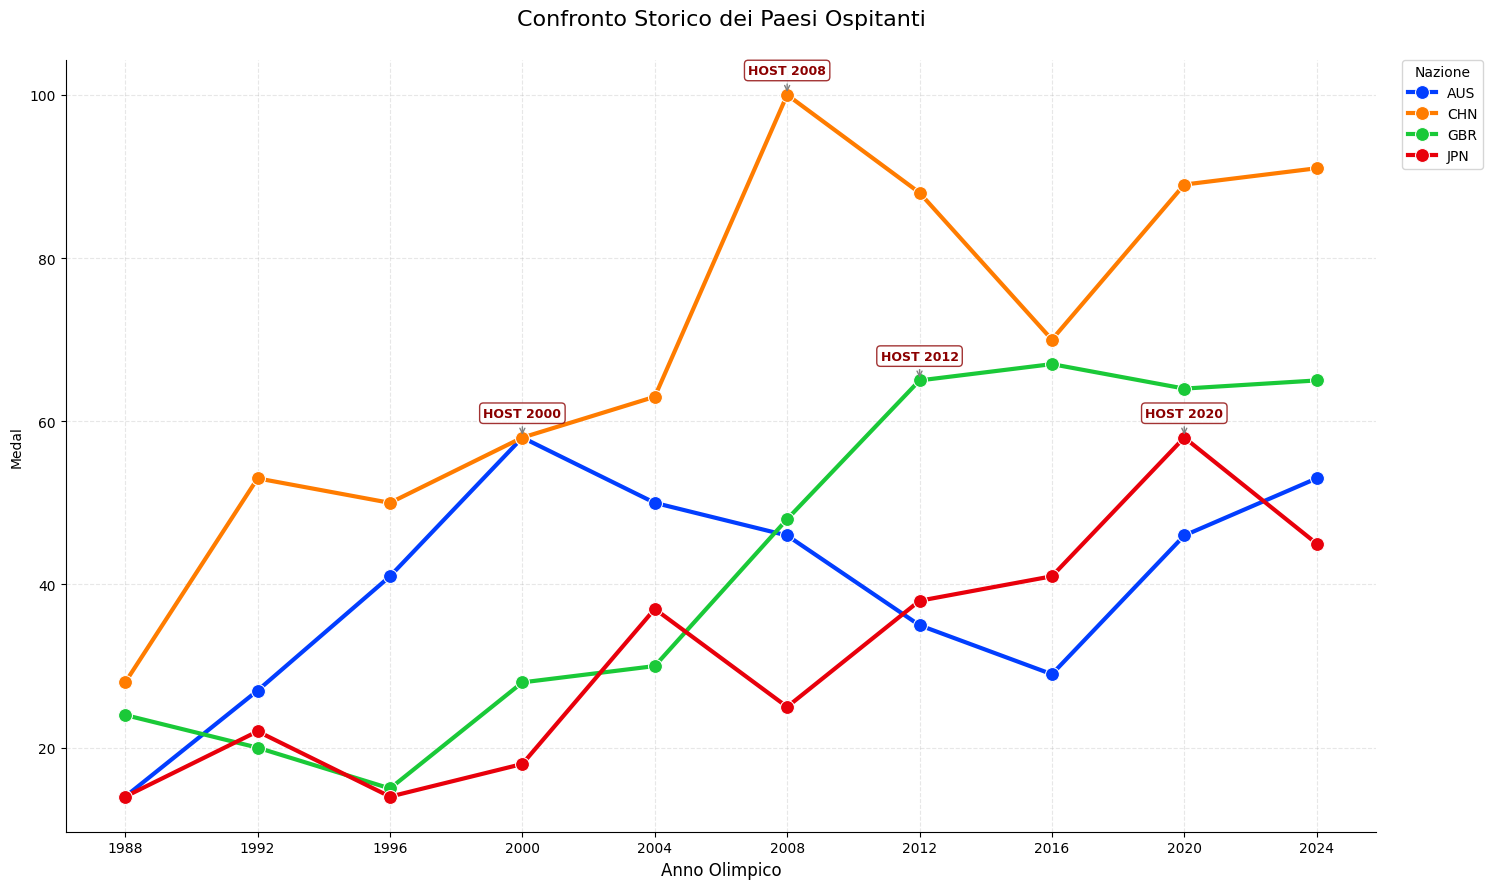

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

hosts_for_plot = {
    2008: "CHN",
    2012: "GBR",
    2000: "AUS",
    2020: "JPN"
}

host_list_for_plot = list(hosts_for_plot.values())
df_olympics_host_for_plot = df_olympics[(df_olympics['NOC'].isin(host_list_for_plot)) & (df_olympics['Year']>=1988)]

plt.figure(figsize=(15, 9))

sns.lineplot(data=df_olympics_host_for_plot, x='Year', y='Medal', hue='NOC', 
             marker='o', markersize=10, linewidth=3, palette='bright')

#plt.xticks(df_olympics_hosts['Year'].unique())
plt.xticks(range(1988,2028, 4))
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
plt.xlabel('Anno Olimpico', fontsize=12)


for year_host, noc_host in hosts_for_plot.items():
    target_row = df_olympics_hosts[(df_olympics_hosts['NOC'] == noc_host) & (df_olympics_hosts['Year'] == year_host)]

    if not target_row.empty:
        y_value = target_row['Medal'].values[0]

        plt.annotate(f'HOST {year_host}', 
         (year_host, y_value),
         textcoords="offset points", 
         xytext=(0, 15), # 15 punti sopra il marker
         ha='center', 
         fontsize=9,
         fontweight='bold',
         color='darkred',
         arrowprops=dict(arrowstyle='->', color='gray', lw=1), # Aggiungiamo una freccetta per chiarezza
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", alpha=0.8))


plt.title('Confronto Storico dei Paesi Ospitanti', fontsize=16, pad=25)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(title='Nazione', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

sns.despine()
plt.tight_layout()
plt.show()

In [14]:
deltas = []
results_within = []

for noc in host_list:
    host_year = [y for y, n in hosts.items() if n == noc]

    host_rows = df_olympics_hosts[
        (df_olympics_hosts['NOC'] == noc) & (df_olympics_hosts['Year'].isin(host_year))
    ]
    other_rows = df_olympics_hosts[
        (df_olympics_hosts['NOC'] == noc) & (~df_olympics_hosts['Year'].isin(host_year))
    ]

    avg_host_medal_percentage  = host_rows['Percentage'].mean()
    avg_other    = other_rows['Percentage'].mean()
    delta        = avg_host_medal_percentage - avg_other
    delta_pct    = (delta / avg_other) * 100 if avg_other > 0 else np.nan

    deltas.append(delta)
    results_within.append({
        'country': noc,
        'Media_Medaglie_Host': avg_host_medal_percentage,
        'Media_Anni_NonHost': avg_other,
        'Delta': delta,
        'Delta_Pct': delta_pct,
    })
    print(f"  {noc} : Media Percentuali Medaglie Vinte Host={avg_host_medal_percentage:.6f}  |  "
      f"Media altri anni={avg_other:.6f}  |  "
      f"Delta={delta:+.1f} ({delta_pct:+.1f}%)")

df_within = pd.DataFrame(results_within)
df_within = df_within.drop_duplicates(subset='country')

  JPN : Media Percentuali Medaglie Vinte Host=5.579397  |  Media altri anni=3.412256  |  Delta=+2.2 (+63.5%)
  MEX : Media Percentuali Medaglie Vinte Host=1.707780  |  Media altri anni=0.360761  |  Delta=+1.3 (+373.4%)
  GER : Media Percentuali Medaglie Vinte Host=17.666667  |  Media altri anni=8.373772  |  Delta=+9.3 (+111.0%)
  CAN : Media Percentuali Medaglie Vinte Host=1.794454  |  Media altri anni=1.730726  |  Delta=+0.1 (+3.7%)
  KOR : Media Percentuali Medaglie Vinte Host=4.471545  |  Media altri anni=2.174361  |  Delta=+2.3 (+105.6%)
  ESP : Media Percentuali Medaglie Vinte Host=2.706027  |  Media altri anni=1.161265  |  Delta=+1.5 (+133.0%)
  USA : Media Percentuali Medaglie Vinte Host=12.009512  |  Media altri anni=13.322464  |  Delta=-1.3 (-9.9%)
  AUS : Media Percentuali Medaglie Vinte Host=6.270270  |  Media altri anni=3.593528  |  Delta=+2.7 (+74.5%)
  GRE : Media Percentuali Medaglie Vinte Host=1.725998  |  Media altri anni=0.433879  |  Delta=+1.3 (+297.8%)
  CHN : Media

In [15]:
from scipy.stats import skew

s = skew(df_within['Delta'])
print(f"Skewness: {s:.4f}")

Skewness: 1.6260


In [16]:
from scipy.stats import binomtest

n_positivi = np.sum(df_within['Delta'] > 0)
n_totale = len(df_within['Delta'])

sign_test_result = binomtest(n_positivi, n=n_totale, p=0.5, alternative='two-sided')

print(f"Differenze positive: {n_positivi} su {n_totale}")
print(f"P-value: {sign_test_result.pvalue:.4f}")

Differenze positive: 12 su 13
P-value: 0.0034


In [17]:
from scipy.stats import wilcoxon

stat, p_val = wilcoxon(df_within['Media_Medaglie_Host'], df_within['Media_Anni_NonHost'], alternative='greater')
print(f"Statistica del test: {stat}")
print(f"P-value: {p_val:.4f}")

Statistica del test: 87.0
P-value: 0.0009


In [18]:
df_gdp = pd.read_csv('./data/GDP/gdp_total.csv', skiprows=4)
df_olympics['ISO'] = df_olympics['NOC'].map(noc_to_iso).fillna(df_olympics['NOC'])
df_olympics.head()

,NOC,Year,Medal,is_host,Percentage,ISO
0,AFG,1964,0,0,0.0,AFG
1,AFG,1968,0,0,0.0,AFG
2,AFG,1972,0,0,0.0,AFG
3,AFG,1988,0,0,0.0,AFG
4,AFG,1996,0,0,0.0,AFG


In [19]:
from scipy.stats import gmean

target_years = [1964, 1968, 1972, 1976, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024]
gdp_processed_data = []

for year in target_years:
    window = [str(y) for y in range(year - 3, year + 1)]
    
    temp_df = df_gdp[['Country Code']].copy()
    temp_df['Year'] = year
    temp_df['GDP_Geom_Mean'] = df_gdp[window].apply(
        lambda x: gmean(x.dropna()) if x.notnull().any() else np.nan, axis=1
    )
    gdp_processed_data.append(temp_df)

# Creazione del dataframe GDP in formato "long"
df_gdp_final = pd.concat(gdp_processed_data)
df_gdp_final.head()

,Country Code,Year,GDP_Geom_Mean
0,ABW,1964,NaN
1,AFE,1964,2.839423e+10
2,AFG,1964,NaN
3,AFW,1964,1.410728e+10
4,AGO,1964,NaN


In [20]:
df_olympics_gdp = pd.merge(
    df_olympics,
    df_gdp_final,
    left_on=['ISO', 'Year'],
    right_on=['Country Code', 'Year'],
    how='left'
)

df_olympics_gdp = df_olympics_gdp.drop(columns=['Country Code'])
df_olympics_gdp.head()

,NOC,Year,Medal,is_host,Percentage,ISO,GDP_Geom_Mean
0,AFG,1964,0,0,0.0,AFG,NaN
1,AFG,1968,0,0,0.0,AFG,NaN
2,AFG,1972,0,0,0.0,AFG,NaN
3,AFG,1988,0,0,0.0,AFG,NaN
4,AFG,1996,0,0,0.0,AFG,NaN


In [21]:
yearly_correlation = df_olympics_gdp.groupby('Year').apply(
    lambda x: x['Percentage'].corr(x['GDP_Geom_Mean'], method='spearman')
)

print(yearly_correlation)

Year
1964    0.657628
1968    0.664404
1972    0.688908
1976    0.676049
1988    0.644296
1992    0.686920
1996    0.652784
2000    0.670057
2004    0.683186
2008    0.673528
2012    0.668123
2016    0.685533
2020    0.651082
2024    0.649676
dtype: float64


In [22]:
df_population = pd.read_csv('./data/population/population.csv', skiprows=4)

target_years = [1964, 1968, 1972, 1976, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024]
pop_processed_data = []

for year in target_years:
    window = [str(y) for y in range(year - 3, year + 1)]
    
    temp_df = df_population[['Country Code']].copy()
    temp_df['Year'] = year
    temp_df['Population_Geom_Mean'] = df_population[window].apply(
        lambda x: gmean(x.dropna()) if x.notnull().any() else np.nan, axis=1
    )
    pop_processed_data.append(temp_df)

df_population_final = pd.concat(pop_processed_data)

df_olympics_pop = pd.merge(
    df_olympics,
    df_population_final,
    left_on=['ISO', 'Year'],
    right_on=['Country Code', 'Year'],
    how='left'
)

df_olympics_pop = df_olympics_pop.drop(columns=['Country Code'])
df_olympics_pop.head()

,NOC,Year,Medal,is_host,Percentage,ISO,Population_Geom_Mean
0,AFG,1964,0,0,0.0,AFG,9.506693e+06
1,AFG,1968,0,0,0.0,AFG,1.038785e+07
2,AFG,1972,0,0,0.0,AFG,1.142798e+07
3,AFG,1988,0,0,0.0,AFG,1.143940e+07
4,AFG,1996,0,0,0.0,AFG,1.647183e+07


In [23]:
yearly_correlation = df_olympics_pop.groupby('Year').apply(
    lambda x: x['Percentage'].corr(x['Population_Geom_Mean'], method='spearman')
)

# Visualizzazione dei risultati
print(yearly_correlation)

Year
1964    0.492175
1968    0.504393
1972    0.541326
1976    0.506511
1988    0.503505
1992    0.492770
1996    0.514203
2000    0.483528
2004    0.509060
2008    0.500601
2012    0.434991
2016    0.480924
2020    0.467844
2024    0.431100
dtype: float64
